# Positional Encoding


## Permutation Invariance

Self-attention computes:

$$\text{Attention}(XW^Q,\; XW^K,\; XW^V)$$

If we permute the rows of $X$ (reorder the sequence), the output gets permuted in the same way. The model has no notion of position; "the cat sat" and "sat the cat" produce equivalent representations (up to row reordering).

To inject position information:

$$x_i \;\to\; x_i + PE(i), \quad PE(i) \in \mathbb{R}^{d_{\text{model}}}$$

## Sinusoidal Positional Encoding

Define for position $pos$ and dimension index $i$:

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right)$$

$$PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right)$$

Each dimension has a different frequency: from wavelength $2\pi$ (at $i=0$) to wavelength $2\pi \cdot 10000$ (at $i = d_{\text{model}}/2 - 1$).

---

### Key Property: Relative Positions as Linear Transformations

For any fixed offset $k$, $PE(pos+k)$ can be written as a linear function of $PE(pos)$.

Let $\omega_i = \frac{1}{10000^{\,2i/d_{\text{model}}}}$. Expand using the angle addition formula:

$$PE(pos+k,\, 2i) = \sin(\omega_i \cdot pos + \omega_i \cdot k) = \cos(\omega_i k)\,\sin(\omega_i\, pos) + \sin(\omega_i k)\,\cos(\omega_i\, pos)$$

$$PE(pos+k,\, 2i+1) = \cos(\omega_i \cdot pos + \omega_i \cdot k) = -\sin(\omega_i k)\,\sin(\omega_i\, pos) + \cos(\omega_i k)\,\cos(\omega_i\, pos)$$

In matrix form for each pair of dimensions $(2i, 2i+1)$:

$$\begin{pmatrix} PE(pos+k,\, 2i) \\ PE(pos+k,\, 2i+1) \end{pmatrix} = \begin{pmatrix} \cos(\omega_i k) & \sin(\omega_i k) \\ -\sin(\omega_i k) & \cos(\omega_i k) \end{pmatrix} \begin{pmatrix} PE(pos,\, 2i) \\ PE(pos,\, 2i+1) \end{pmatrix}$$

This is a **rotation matrix** $R_{\omega_i k}$. The transformation from $PE(pos)$ to $PE(pos+k)$ is:
- **Linear** in $PE(pos)$
- **Independent of $pos$** (depends only on $k$)

The model can learn to attend to relative positions because dot products $PE(pos)^\top PE(pos+k)$ depend only on $k$.

## Learned Positional Embeddings

Alternative: learn a matrix $P \in \mathbb{R}^{\text{max\_len} \times d_{\text{model}}}$, index by position.

- **Pro:** more flexible, can learn arbitrary position patterns
- **Con:** can't extrapolate beyond `max_len` seen during training
- BERT, GPT-2 use learned; original Transformer uses sinusoidal
- In practice: similar performance for fixed `max_len` tasks

## RoPE (Rotary Position Embedding)

Used in LLaMA, GPT-NeoX, modern LLMs.

Instead of adding position to the input, RoPE applies rotation to $Q$ and $K$ in attention:

$$\tilde{q}_m = R_m\, q, \quad \tilde{k}_n = R_n\, k$$

$$\tilde{q}_m^\top \tilde{k}_n = q^\top R_m^\top R_n\, k = q^\top R_{n-m}\, k$$

The attention score depends only on **relative position** $(n - m)$. $R_\theta$ is a block-diagonal rotation matrix applied to pairs of dimensions.

This is the dominant approach in modern LLMs because it naturally encodes relative position and extrapolates better than absolute position encodings.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

## Implementation

In [6]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding from "Attention Is All You Need".

    Creates a (max_len, d_model) matrix of position encodings and registers
    it as a buffer (not a parameter — no gradients).

    Args:
        d_model: embedding dimension
        max_len: maximum sequence length
    """
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # TODO: Create the PE matrix of shape (max_len, d_model)
        # Step 1: Create position indices: pos = [0, 1, 2, ..., max_len-1] as column vector
        # Step 2: Create dimension indices: i = [0, 1, 2, ..., d_model/2-1]
        # Step 3: Compute frequencies: 1 / 10000^(2i/d_model)
        # Step 4: Compute outer product: pos * freq → (max_len, d_model/2)
        # Step 5: Apply sin to even indices, cos to odd indices
        # Step 6: Register as buffer with self.register_buffer('pe', pe)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        i = torch.arange(d_model // 2)
        freq = torch.exp(-2 * i * np.log(10000) / d_model)
        outer = pos * freq
        pe[:, 0::2] = torch.sin(outer)
        pe[:, 1::2] = torch.cos(outer)

        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model) — input embeddings
        Returns:
            (batch, seq_len, d_model) — embeddings + positional encoding
        """
        # TODO: Add positional encoding to input (slice pe to match seq_len)
        return x + self.pe[:, :x.size(1)]

In [10]:
class LearnedPositionalEmbedding(nn.Module):
    """
    Learned positional embeddings — a simple lookup table.

    Args:
        d_model: embedding dimension
        max_len: maximum sequence length
    """
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # TODO: Create an nn.Embedding(max_len, d_model)
        self.embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)
        """
        seq_len = x.size(1)
        # TODO: Create position indices [0, 1, ..., seq_len-1] and look up embeddings
        positions = torch.arange(seq_len).unsqueeze(0)
        return x + self.embedding(positions)

## Verification

In [11]:
d_model = 64
max_len = 100

sin_pe = SinusoidalPositionalEncoding(d_model, max_len)
learned_pe = LearnedPositionalEmbedding(d_model, max_len)

x = torch.randn(2, 20, d_model)

# Test sinusoidal
out_sin = sin_pe(x)
assert out_sin.shape == x.shape, f"Expected {x.shape}, got {out_sin.shape}"

# Test learned
out_learned = learned_pe(x)
assert out_learned.shape == x.shape, f"Expected {x.shape}, got {out_learned.shape}"

# Verify sinusoidal PE values at specific positions
pe_matrix = sin_pe.pe.squeeze(0)  # (max_len, d_model)

# Check: PE(0, 0) = sin(0) = 0
assert abs(pe_matrix[0, 0].item()) < 1e-6, f"PE(0,0) should be 0, got {pe_matrix[0, 0].item()}"

# Check: PE(0, 1) = cos(0) = 1
assert abs(pe_matrix[0, 1].item() - 1.0) < 1e-6, f"PE(0,1) should be 1, got {pe_matrix[0, 1].item()}"

# Check: different positions have different encodings
assert not torch.allclose(pe_matrix[0], pe_matrix[1]), "Positions 0 and 1 should differ"

print("All checks passed")

All checks passed


## Experiment: Visualizing Positional Encodings

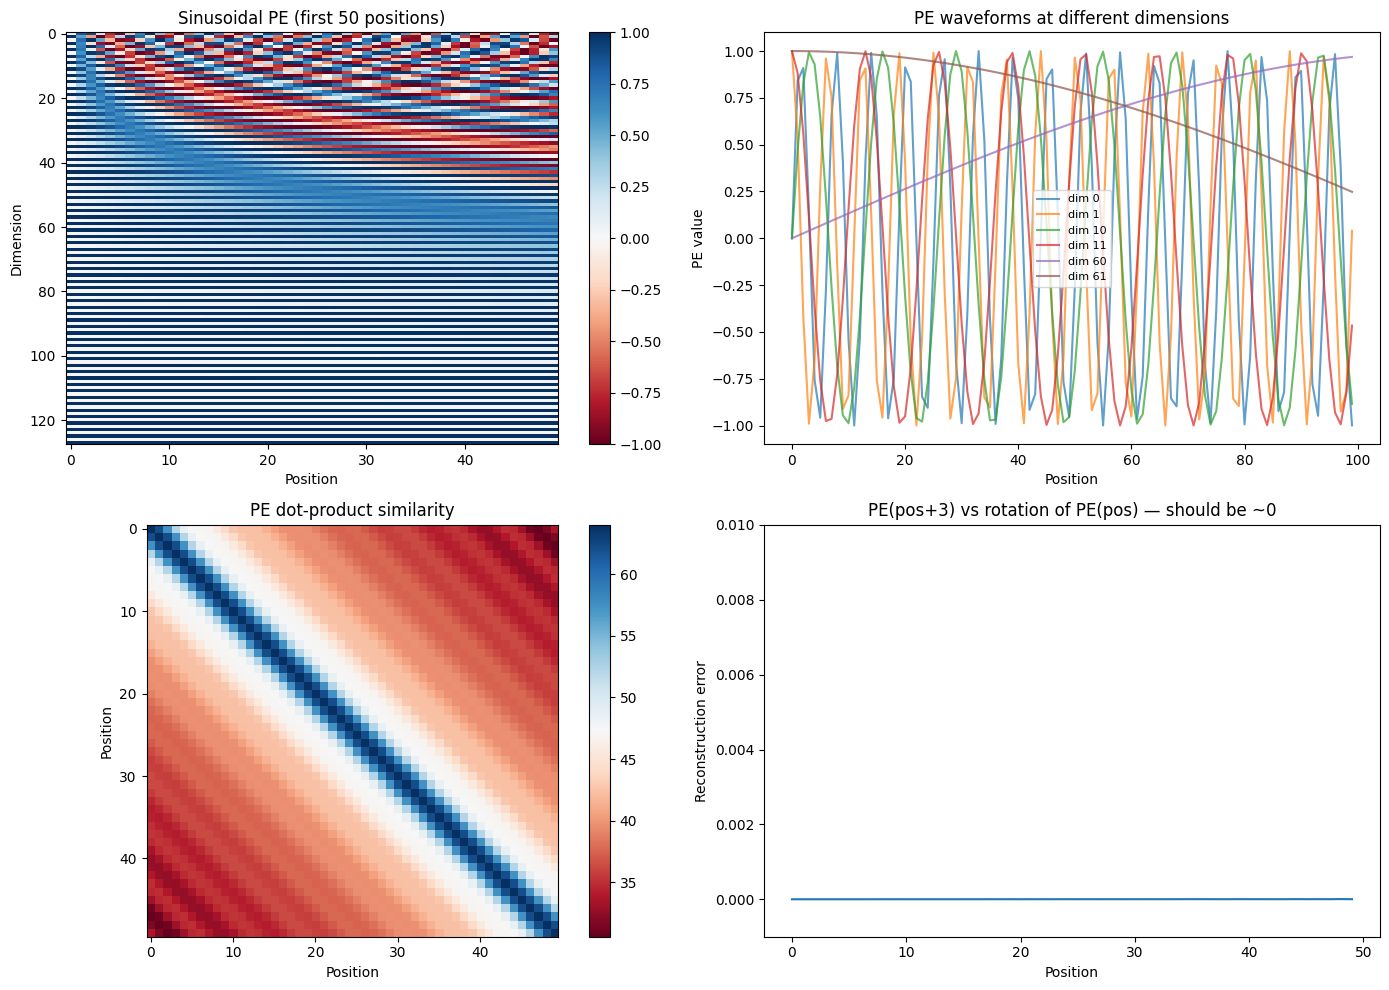

In [12]:
d_model = 128
pe = SinusoidalPositionalEncoding(d_model, max_len=200)
pe_matrix = pe.pe.squeeze(0).numpy()  # (200, 128)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Full PE heatmap
ax = axes[0, 0]
im = ax.imshow(pe_matrix[:50, :].T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Position')
ax.set_ylabel('Dimension')
ax.set_title('Sinusoidal PE (first 50 positions)')
plt.colorbar(im, ax=ax)

# 2. Individual dimension waveforms
ax = axes[0, 1]
for dim in [0, 1, 10, 11, 60, 61]:
    ax.plot(pe_matrix[:100, dim], label=f'dim {dim}', alpha=0.7)
ax.set_xlabel('Position')
ax.set_ylabel('PE value')
ax.set_title('PE waveforms at different dimensions')
ax.legend(fontsize=8)

# 3. Similarity between positions (dot product of PE vectors)
ax = axes[1, 0]
similarity = pe_matrix[:50] @ pe_matrix[:50].T
im = ax.imshow(similarity, cmap='RdBu')
ax.set_xlabel('Position')
ax.set_ylabel('Position')
ax.set_title('PE dot-product similarity')
plt.colorbar(im, ax=ax)

# 4. Verify linear transformation property
ax = axes[1, 1]
# For a fixed offset k, plot ||PE(pos+k) - M_k @ PE(pos)||
# where M_k is the theoretical rotation matrix
k = 3
errors = []
for pos in range(50):
    pe_pos = pe_matrix[pos]
    pe_pos_k = pe_matrix[pos + k]

    # Reconstruct using rotation for each pair of dimensions
    reconstructed = np.zeros(d_model)
    for i in range(d_model // 2):
        omega = 1.0 / (10000 ** (2 * i / d_model))
        cos_wk = np.cos(omega * k)
        sin_wk = np.sin(omega * k)
        reconstructed[2*i] = cos_wk * pe_pos[2*i] + sin_wk * pe_pos[2*i+1]
        reconstructed[2*i+1] = -sin_wk * pe_pos[2*i] + cos_wk * pe_pos[2*i+1]

    errors.append(np.linalg.norm(pe_pos_k - reconstructed))

ax.plot(errors)
ax.set_xlabel('Position')
ax.set_ylabel('Reconstruction error')
ax.set_title(f'PE(pos+{k}) vs rotation of PE(pos) — should be ~0')
ax.set_ylim(-0.001, 0.01)

plt.tight_layout()
plt.show()

## Experiment: Does Position Matter?

Train a simple model on sequence reversal a task that requires position information.

In [ ]:
# Sequence reversal: can't solve without position info
# Input: [3, 1, 4, 1, 5] → Output: [5, 1, 4, 1, 3]

from torch.utils.data import DataLoader, TensorDataset

vocab_size = 10
seq_len = 8
d_model = 32
n_samples = 5000

# Generate data
data = torch.randint(1, vocab_size, (n_samples, seq_len))
targets = data.flip(dims=[1])

train_data = data[:4000]
train_targets = targets[:4000]
test_data = data[4000:]
test_targets = targets[4000:]


# Simple model: Embedding + attention + linear
class SimpleAttentionModel(nn.Module):
    def __init__(self, vocab_size, d_model, use_position=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.use_position = use_position
        if use_position:
            self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=seq_len + 10)
        self.attention = nn.MultiheadAttention(d_model, num_heads=4, batch_first=True)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        if self.use_position:
            x = self.pos_enc(x)
        x, _ = self.attention(x, x, x)
        return self.fc(x)


# Train both models
def train_model(model, train_data, train_targets, epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    losses = []
    for epoch in range(epochs):
        logits = model(train_data)
        loss = F.cross_entropy(logits.view(-1, vocab_size), train_targets.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


model_with_pos = SimpleAttentionModel(vocab_size, d_model, use_position=True)
model_no_pos = SimpleAttentionModel(vocab_size, d_model, use_position=False)

losses_with = train_model(model_with_pos, train_data, train_targets)
losses_without = train_model(model_no_pos, train_data, train_targets)

# Evaluate
with torch.no_grad():
    pred_with = model_with_pos(test_data).argmax(dim=-1)
    pred_without = model_no_pos(test_data).argmax(dim=-1)
    acc_with = (pred_with == test_targets).float().mean().item()
    acc_without = (pred_without == test_targets).float().mean().item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses_with, label='With positional encoding')
ax1.plot(losses_without, label='Without positional encoding')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Training loss')
ax1.legend()

ax2.bar(['With PE', 'Without PE'], [acc_with, acc_without])
ax2.set_ylabel('Test accuracy')
ax2.set_title('Sequence reversal accuracy')
ax2.set_ylim(0, 1)
for i, v in enumerate([acc_with, acc_without]):
    ax2.text(i, v + 0.02, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

## Connections

- **Original Transformer (2017):** sinusoidal fixed encoding
- **BERT, GPT-2:** learned absolute position embeddings (max 512 or 1024 tokens)
- **RoPE (2021):** rotary embeddings in LLaMA, Mistral: encode relative position, extrapolate better
- **ALiBi (2021):** no position embedding at all: just add linear bias to attention scores based on distance
- **The trend:** from absolute to relative position encoding, with better length generalization
- **Next notebook:** assembling the full transformer encoder block (attention + FFN + residuals + layer norm)

## Key Equations
$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right), \quad PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right)$$

$PE(pos+k)$ is a linear transformation (rotation) of $PE(pos)$, independent of $pos$ : enabling the model to learn relative position attention.